# Morris Method for NREL 5MW Landbased Reference Turbine Erosion Experiment
This file is set up to explore sensitivity for 5 inputs:
- Erosion Severity Level: [0,1]
- Wind Speed: [3, 25] m/s
- Yaw Misalignment: [-15,15] degrees
- Air Density: [1.1, 1.42] kg/m^3
- Wind Shear: [0.0, 0.5]

Which ever of the five non-erosion factors has the least impact will be fixed for the remaining numerical experiments.

We plan to repeat this experiment for 3 different **erosion profile shapes**.  The **erosion severity value** for each **blade region** is a number between [0,1] that scales the lift and drag coefficients for the airfoils in that region.  The lift is scaled from 1 to 0.53 at maximum erosion.  The drag is scaled from 1 to 5 at maximum erosion.

The erosion profile shape is a function which will return the erosion severity value for each blade region.  We will use a function which returns an erosion severity value based on the distance of the center of each region from the hub.  The first erosion profile shape will be linear.  The second will be quadratic.  The third will be a linear function with non-zero y axis intercept.  The erosion severity level is a scalar that shifts the slope of each function.

In [1]:
# For testing with active control of the blade pitch
from SALib.sample.morris.morris import sample
import numpy as np

# Define the model inputs
# recall that our model takes input vectors of the form:

# [wind_direction,wind_speed,blade_angle,air_density,erosion_blade1_region1,..._region6,
# erosion_blade2_region1,...,_region6,erosion_blade3_region1,..._region6]

problem = {
    'num_vars': 5,
    'names': ['WindDir', 'WindSpeed','AirDensity','WindShear','ErosionSeverity'],
    'bounds': [[0,1],
               [0,1],
               [0,1],
               [0,1],
               [0,1],
               ]
}

# N = number of trajectories to generate
N = 100;

# num_levels = number of partitions for the input dimensions
num_levels = 10;

# optimal trajectories
opt = 25;

# Generate samples
param_values = sample(problem, N, num_levels, opt)

# Save the outputs
# np.savetxt("MorrisInputs.txt", param_values) - we do NOT want to rewrite this file

# Run this after Simulation
Do not re-run the above cell.

In [2]:
from SALib.analyze.morris import analyze
import pandas as pd
import numpy as np

problem = {
    'num_vars': 5,
    'names': ['WindDir', 'WindSpeed','AirDensity','WindShear','ErosionSeverity'],
    'bounds': [[0,1],
               [0,1],
               [0,1],
               [0,1],
               [0,1],
               ]
}
inputs = np.loadtxt("MorrisInputs.txt", float)

# Load in the corresponding Morris results file
Exp1ID = "Data/Exp1/"
ShapeNum = 1
morris_exp_data = pd.read_table(Exp1ID+"LARGE2ExperimentResultTable"+str(ShapeNum)+".txt",delimiter = ',')

In [3]:
allnames = morris_exp_data.columns.tolist()
spacer = 20
for i in range(30):
    
    spc1 = spacer - len(allnames[4*i])-len(str(4*i))
    spc2 = spacer - len(allnames[4*i+1])-len(str(4*i+1))
    spc3 = spacer - len(allnames[4*i+2])-len(str(4*i+2))
    a = str(4*i)+" "+allnames[4*i]+spc1*" "
    b = str(4*i+1)+" "+allnames[4*i+1]+spc2*" "
    c = str(4*i+2)+" "+allnames[4*i+2]+spc3*" "
    d = str(4*i+3)+" "+allnames[4*i+3]
    print(a+b+c+d)


0 WindDirection      1 WindSpeed          2 AirDensity         3 WindShear
4 B1Er1              5 B1Er2              6 B1Er3              7 B1Er4
8 B1Er5              9 B1Er6              10 B2Er1             11 B2Er2
12 B2Er3             13 B2Er4             14 B2Er5             15 B2Er6
16 B3Er1             17 B3Er2             18 B3Er3             19 B3Er4
20 B3Er5             21 B3Er6             22 Alpha             23 Style
24 Timemean          25 RootFxb1mean      26 RootFyb1mean      27 RootFzc1mean
28 RootMxb1mean      29 RootMyb1mean      30 RootMzc1mean      31 TipDxc1mean
32 TipDyc1mean       33 TipDzc1mean       34 TipDxb1mean       35 TipDyb1mean
36 TipALxb1mean      37 TipALyb1mean      38 TipALzb1mean      39 TipRDxb1mean
40 TipRDyb1mean      41 HSShftVmean       42 B1Pitchmean       43 B1N1Clmean
44 B1N2Clmean        45 B1N3Clmean        46 B1N4Clmean        47 B1N5Clmean
48 B1N6Clmean        49 B1N1Cdmean        50 B1N2Cdmean        51 B1N3Cdmean
52 B1N4Cdmean        

In [4]:
morris_exp_data.shape

(150, 156)

# Note on Indexing

Observe that the first 24 columns come from the input file.  Then, the next column is not useful.  The cycle repeats for new suffix after 33 entries.  Thus, starting from the 24 entry, we can define the start and stop of each new output-statistic cycle.

In [6]:
batchnum = 0 #[0-3]
start = 24 + 33*batchnum + 1
stop = 24 + 33*(batchnum+1) 
batch = allnames[start:stop]
for i in range(17):
    try:
        spc1 = spacer - len(batch[4*i]) - len(str(4*i))
    except:
        spc1 = " "
    try:
        spc2 = spacer - len(batch[4*i+1]) - len(str(4*i+1))
    except:
        spc2 = " "
    try:
        spc3 = spacer - len(batch[4*i+2]) - len(str(4*i+2))
    except:
        spc3 = " "
    try:
        a = str(4*i) + " " + batch[4*i] + spc1*" "
    except: 
        a = " "
    try:
        b = str(4*i+1) + " " + batch[4*i+1] + spc2*" "
    except: 
        b = " "
    try:
        c = str(4*i+2) + " " + batch[4*i+2] + spc3*" "
    except: 
        c = " "
    try:
        d = str(4*i+3) + " " + batch[4*i+3]
    except:
        d = " "
    print(a+b+c+d)


0 RootFxb1mean       1 RootFyb1mean       2 RootFzc1mean       3 RootMxb1mean
4 RootMyb1mean       5 RootMzc1mean       6 TipDxc1mean        7 TipDyc1mean
8 TipDzc1mean        9 TipDxb1mean        10 TipDyb1mean       11 TipALxb1mean
12 TipALyb1mean      13 TipALzb1mean      14 TipRDxb1mean      15 TipRDyb1mean
16 HSShftVmean       17 B1Pitchmean       18 B1N1Clmean        19 B1N2Clmean
20 B1N3Clmean        21 B1N4Clmean        22 B1N5Clmean        23 B1N6Clmean
24 B1N1Cdmean        25 B1N2Cdmean        26 B1N3Cdmean        27 B1N4Cdmean
28 B1N5Cdmean        29 B1N6Cdmean        30 GenPwrmean        31 GenTqmean
    
    
    
    
    
    
    
    
    


Batch 2: GenPwrskew
                       mu   mu_star     sigma  mu_star_conf
WindDir          0.008825  0.063139  0.087781      0.022352
WindSpeed        0.097123  0.217453  0.465293      0.158227
AirDensity      -0.013187  0.043988  0.059051      0.016205
WindShear        0.026544  0.069304  0.079906      0.018953
ErosionSeverity -0.067001  0.126059  0.304329      0.113015
*****************
Top 3 Influential Inputs
WindSpeed
ErosionSeverity
WindDir


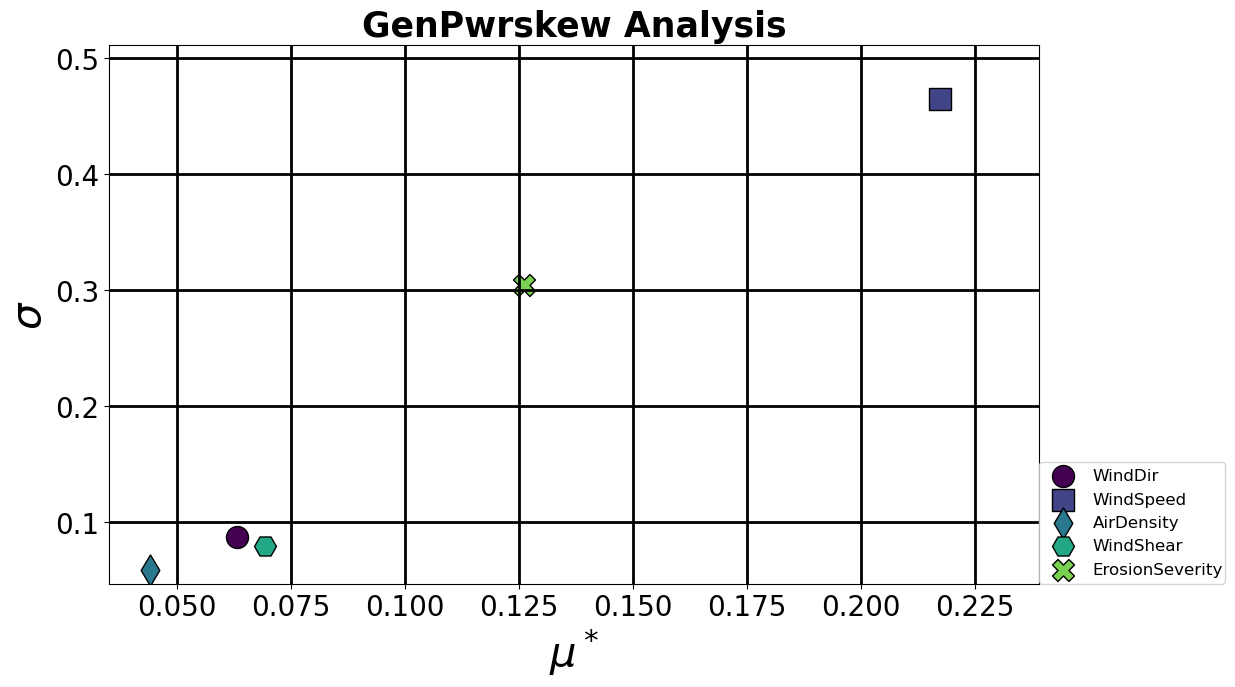

In [10]:
# Load in the corresponding Morris results file
Exp1ID = "Data/Exp1/"
ShapeNum = 1
morris_exp_data = pd.read_table(Exp1ID+"LARGE2ExperimentResultTable"+str(ShapeNum)+".txt",delimiter = ',')

# Select which type of statistic to look at 
batchnum = 2 #[0-3]
start = 24 + 33*batchnum + 1
stop = 24 + 33*(batchnum+1) 
batch = allnames[start:stop]

# Select the output needed
select = 30 # 30 -- Generator Power

n = 24 + 33*batchnum + 1 + select

# Output name
outname = allnames[n]
name = batch[select]
print("Batch "+str(batchnum)+": "+outname)
outputs = morris_exp_data[[allnames[n]]].to_numpy()
outputs = outputs.astype(np.float64)

def NormalizeData(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))
mini = np.min(outputs)
maxi = np.max(outputs)
outputs = NormalizeData(outputs)

# Number of inputs
dim = np.shape(inputs)
dim = dim[1]

Si = analyze(problem, inputs, outputs, conf_level=0.95,
                    print_to_console=True, num_levels=10)

import matplotlib.pyplot as plt

# We want to plot the mu_star on the xaxis and the sigma on the y axis

# But first let's try something out...
stor = np.zeros((2,dim))
stor[0,:] = Si["mu_star"]
stor[1,:] = Si["sigma"]

vals = np.zeros((dim,))

for i in range(dim):
    vals[i] = np.linalg.norm(stor[:,i])
tempvals = vals

print("*****************")
print("Top 3 Influential Inputs")

# List off the top 3 influential inputs...
for j in range(3):
    ind = np.argmax(tempvals)
    print(Si["names"][ind])
    tempvals[ind] = 0
    
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

stor = np.zeros((2,dim))
stor[0,:] = Si["mu_star"]
stor[1,:] = Si["sigma"]

vals = np.zeros((dim,))
for i in range(dim):
    vals[i] = np.linalg.norm(stor[:,i])

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=0, vmax=dim)
nomr1 = plt.Normalize(vmin=min(vals),vmax=max(vals))
#plt.yscale("log")
#plt.xscale("log")
ms = ["o","s","d","H","X","*","h","X","8","H","s","*","h","X","8","H","s","*","h","X","8"];
for i in range(len(Si["names"])):
    cl = cmap(norm(i))
    scale = 250 #400*nomr1(vals[i])
    ax.scatter(Si["mu_star"][i], Si["sigma"][i], marker = ms[i],color=cl, s=scale, label=Si["names"][i], edgecolors='black')
              
#ax.legend(loc="upper left")
ax.legend(bbox_to_anchor=(1,0,.2,2), loc='lower left',
           ncols=1,mode="expand", borderaxespad=0,fontsize=12)
ax.grid(True)
ax.set_xlabel("$\mu^*$",fontsize=30)
ax.set_ylabel("$\sigma$",fontsize=30)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.grid(color='k', linewidth=2)
ax.set_xlim([min(Si["mu_star"])*.8,max(Si["mu_star"])*1.1])
ax.set_ylim([min(Si["sigma"])*.8,max(Si["sigma"])*1.1])
outname = outname+" Analysis"
ax.set_title(outname,fontsize = 25,fontweight = 'bold')
plt.show()

In [7]:
print(vals)

[0.43202085 0.43423207 0.32134063 0.36937254 0.11721124]


# Generating Table of All Morris Results

- Note: We standardize the results of each output by mapping them to the unit inverval before computing Effects

## Central Questions

1. What is the average Mu and Sigma across statistics and ouputs for each erosion profile?

2. For given groups of statistics, what is the mu and sigma for the mean statistic? 

## Organization of Data

Organize the data in the following way.  There will be a seperate table for each erosion shape experiment.  Each row of the table will be a different output-statistic pair, with all outputs for a given statistic given before continuing.  The columns will be as follows for [wind_dir,wind_speed,air_dens,wind_shear,erosion]:

1. Variable n: Mu_Star
2. Variable n: Sigma
3. Variable n: Confidence interval of Mu_Star
4. Variable n: Euclidean distance to (mu_star, sigma)

Also provide: 
min, max, mean for each row. (from the raw data)

Save the tables as `Morris_Results_#.txt`

In [11]:
print(Si["names"])
g = Si["mu_star"][0]
print(g)
print(Si["mu_star"][0])
print(Si["sigma"][0])
print(Si["mu_star_conf"][0],"\n")

for i in range(5):
    print(np.sqrt(Si["mu_star"][i]**2+Si["sigma"][i]**2))

['WindDir', 'WindSpeed', 'AirDensity', 'WindShear', 'ErosionSeverity']
0.0631393517380156
0.0631393517380156
0.08778087887698625
0.022351704031793044 

0.10812983138021157
0.5135981676976358
0.07363436388376936
0.10577322935477076
0.3294037660139142


In [34]:
len(allnames)

156

In [12]:
# Collect the data from the target table
# Load in the corresponding Morris results file
Exp1ID = "Data/Exp1/"
for h in range(3):
    ShapeNum = h+1
    morris_exp_data = pd.read_table(Exp1ID+"LARGE2ExperimentResultTable"+str(ShapeNum)+".txt",delimiter = ',')
    # Prepare arrays to hold the data
    allnames = morris_exp_data.columns.tolist()
    datalength = morris_exp_data.shape[1]-1*4-24#remember, we are dropping certain entries
    rowNames = []

    WindDirMu = np.zeros((datalength,))
    WindDirSigma = np.zeros((datalength,))
    WindDirConf = np.zeros((datalength,))
    WindDirNorm = np.zeros((datalength,))

    WindSpeedMu = np.zeros((datalength,))
    WindSpeedSigma = np.zeros((datalength,))
    WindSpeedConf = np.zeros((datalength,))
    WindSpeedNorm = np.zeros((datalength,))

    AirDensityMu = np.zeros((datalength,))
    AirDensitySigma = np.zeros((datalength,))
    AirDensityConf = np.zeros((datalength,))
    AirDensityNorm = np.zeros((datalength,))

    WindShearMu = np.zeros((datalength,))
    WindShearSigma = np.zeros((datalength,))
    WindShearConf = np.zeros((datalength,))
    WindShearNorm = np.zeros((datalength,))

    ErosionSeverityMu = np.zeros((datalength,))
    ErosionSeveritySigma = np.zeros((datalength,))
    ErosionSeverityConf = np.zeros((datalength,))
    ErosionSeverity = np.zeros((datalength,))

    minis = np.zeros((datalength,))

    maxis = np.zeros((datalength,))

    means = np.zeros((datalength,)) 


    for i in range(4):
        # Select the statistic group via "i"
        batchnum = i
        start = 24 + 33*batchnum + 1
        for j in range(32):
            n = 24 + 33*batchnum + 1 + j
            # Select the Output
            rowNames.append(allnames[n])
            outputs = morris_exp_data[[allnames[n]]].to_numpy()
            outputs = outputs.astype(np.float64)
            def NormalizeData(data):
                return (data - np.min(data)) / (np.max(data) - np.min(data))
            mini = np.min(outputs) # Save the minimum
            maxi = np.max(outputs) # Save the maximum
            mean = np.mean(outputs) # Save the mean
            outputs = NormalizeData(outputs) # Normalize the output data
            Si = analyze(problem, inputs, outputs, conf_level=0.95,
                        print_to_console=False, num_levels=10) # Do the analysis

            # Save all the Morris Results
            k=i*32+j
            WindDirMu[k] = Si["mu_star"][0]
            WindDirSigma[k] = Si["sigma"][0]
            WindDirConf[k] = Si["mu_star_conf"][0]
            WindDirNorm[k] = np.sqrt(Si["mu_star"][0]**2+Si["sigma"][0]**2)

            WindSpeedMu[k] = Si["mu_star"][1]
            WindSpeedSigma[k] = Si["sigma"][1]
            WindSpeedConf[k] = Si["mu_star_conf"][1]
            WindSpeedNorm[k] = np.sqrt(Si["mu_star"][1]**2+Si["sigma"][1]**2)

            AirDensityMu[k] = Si["mu_star"][2]
            AirDensitySigma[k] = Si["sigma"][2]
            AirDensityConf[k] = Si["mu_star_conf"][2]
            AirDensityNorm[k] = np.sqrt(Si["mu_star"][2]**2+Si["sigma"][2]**2)

            WindShearMu[k] = Si["mu_star"][3]
            WindShearSigma[k] = Si["sigma"][3]
            WindShearConf[k] = Si["mu_star_conf"][3]
            WindShearNorm[k] = np.sqrt(Si["mu_star"][3]**2+Si["sigma"][3]**2)

            ErosionSeverityMu[k] = Si["mu_star"][4]
            ErosionSeveritySigma[k] = Si["sigma"][4]
            ErosionSeverityConf[k] = Si["mu_star_conf"][4]
            ErosionSeverity[k] = np.sqrt(Si["mu_star"][4]**2+Si["sigma"][4]**2)

            minis[k] = mini

            maxis[k] = maxi

            means[k] = mean

    # Create a dictionary with all of the datarows
    ElementaryDic = {"WindDirMuStar": WindDirMu,
                     "WindDirSigma": WindDirSigma,
                     "WindDirConf": WindDirConf,
                     "WindDirNorm": WindDirNorm,
                     "WindSpeedMuStar": WindSpeedMu,
                     "WindSpeedSigma": WindSpeedSigma,
                     "WindSpeedConf": WindSpeedConf,
                     "WindSpeedNorm": WindSpeedNorm,
                     "AirDensityMuStar": AirDensityMu,
                     "AirDensitySigma": AirDensitySigma,
                     "AirDensityConf": AirDensityConf,
                     "AirDensityNorm": AirDensityNorm, 
                     "WindShearMuStar": WindShearMu,
                     "WindShearSigma": WindShearSigma, 
                     "WindShearConf": WindShearConf,
                     "WindShearNorm": WindShearNorm,  
                     "ErosionSeverityMuStar": ErosionSeverityMu, 
                     "ErosionSeveritySigma": ErosionSeveritySigma, 
                     "ErosionSeverityConf":  ErosionSeverityConf,
                     "ErosionSeverity": ErosionSeverity,
                     "Minimum": minis,
                     "Maximum": maxis,
                     "Means": means}
    # Make a panda using the dictionary, assign the row names via the row_names variable        
    MorrisResults = pd.DataFrame(data=ElementaryDic, index = rowNames)

    MorrisResults.to_parquet("MorrisResultAnalysisTable"+str(ShapeNum)+".parquet")

C:\Users\aidan\AppData\Local\Temp\ipykernel_23304\917615688.py:65: UserWarning: Warning: converting a masked element to nan.
  WindDirMu[k] = Si["mu_star"][0]
C:\Users\aidan\AppData\Local\Temp\ipykernel_23304\917615688.py:67: UserWarning: Warning: converting a masked element to nan.
  WindDirConf[k] = Si["mu_star_conf"][0]
C:\Users\aidan\AppData\Local\Temp\ipykernel_23304\917615688.py:68: UserWarning: Warning: converting a masked element to nan.
  WindDirNorm[k] = np.sqrt(Si["mu_star"][0]**2+Si["sigma"][0]**2)
C:\Users\aidan\AppData\Local\Temp\ipykernel_23304\917615688.py:70: UserWarning: Warning: converting a masked element to nan.
  WindSpeedMu[k] = Si["mu_star"][1]
C:\Users\aidan\AppData\Local\Temp\ipykernel_23304\917615688.py:72: UserWarning: Warning: converting a masked element to nan.
  WindSpeedConf[k] = Si["mu_star_conf"][1]
C:\Users\aidan\AppData\Local\Temp\ipykernel_23304\917615688.py:73: UserWarning: Warning: converting a masked element to nan.
  WindSpeedNorm[k] = np.sqrt(S

In [13]:
MorrisResults.head(32)

,WindDirMuStar,WindDirSigma,WindDirConf,WindDirNorm,WindSpeedMuStar,WindSpeedSigma,WindSpeedConf,WindSpeedNorm,AirDensityMuStar,AirDensitySigma,...,WindShearSigma,WindShearConf,WindShearNorm,ErosionSeverityMuStar,ErosionSeveritySigma,ErosionSeverityConf,ErosionSeverity,Minimum,Maximum,Means
RootFxb1mean,0.033697,0.047562,0.013802,0.058290,0.841885,0.864280,0.143728,1.206545,0.051877,0.075996,...,0.021151,0.007132,0.026880,0.032647,0.038037,0.007092,0.050126,4.440127e+01,258.353692,138.630969
RootFyb1mean,0.057534,0.078909,0.032330,0.097657,0.626665,0.722737,0.130412,0.956586,0.107649,0.159926,...,0.042869,0.013802,0.053033,0.060850,0.081527,0.025743,0.101732,-4.178272e+01,-0.899034,-11.430854
RootFzc1mean,0.010446,0.022306,0.008701,0.024630,1.111768,0.735228,0.291825,1.332888,0.014619,0.040011,...,0.003346,0.001072,0.004650,0.005415,0.016429,0.006307,0.017299,2.035823e+02,621.243266,473.794120
RootMxb1mean,0.060868,0.086981,0.031137,0.106163,0.636843,0.740111,0.193415,0.976388,0.096485,0.150815,...,0.051310,0.017113,0.062280,0.054652,0.066147,0.019030,0.085804,-1.614993e+00,1312.588843,264.093010
RootMyb1mean,0.045149,0.061369,0.016724,0.076187,0.904925,0.979566,0.111311,1.333581,0.064078,0.092584,...,0.022898,0.007475,0.029831,0.032353,0.039436,0.008425,0.051009,1.485983e+03,8934.255078,4140.545793
RootMzc1mean,0.034978,0.056205,0.017663,0.066200,0.716053,0.399369,0.160454,0.819895,0.198336,0.128349,...,0.029029,0.012030,0.046018,0.034766,0.039706,0.007105,0.052775,-6.098146e+01,6.732259,-26.903655
TipDxc1mean,0.049945,0.067902,0.017041,0.084292,0.821973,0.924720,0.176692,1.237233,0.085931,0.103436,...,0.021747,0.007156,0.029826,0.027568,0.037510,0.011831,0.046551,6.583378e-02,4.652112,1.684316
TipDyc1mean,0.067622,0.093930,0.033736,0.115739,1.039800,1.072624,0.188739,1.493890,0.098921,0.133496,...,0.047216,0.019424,0.056581,0.043208,0.044585,0.013638,0.062086,-7.524132e-01,-0.035603,-0.328788
TipDzc1mean,0.059698,0.091137,0.029368,0.108949,0.724592,0.838241,0.208814,1.108008,0.078029,0.140983,...,0.075932,0.027528,0.091524,0.025038,0.031082,0.011271,0.039912,-3.078487e-01,-0.002555,-0.065179
TipDxb1mean,0.050812,0.068270,0.019377,0.085104,0.827431,0.934380,0.192388,1.248082,0.087071,0.103644,...,0.022782,0.008625,0.031015,0.028407,0.037218,0.011881,0.046821,7.453179e-02,4.652112,1.719081


In [14]:
WindDirMu[-100:]

array([0.07716775, 0.07411603, 0.00547838, 0.00565006, 0.18279193,
       0.18013396, 0.09169714, 0.18799566, 0.19288291, 0.23477545,
       0.18695968, 0.1796197 , 0.07604324, 0.17743702, 0.25762594,
       0.1024638 , 0.11759177, 0.15092459, 0.24564343, 0.16795219,
       0.0777598 , 0.05665798, 0.41861646, 0.34887861, 0.34484254,
       0.31457421, 0.26157741, 0.20567808, 0.32691811, 0.25313467,
       0.29899292, 0.28831699, 0.22995541, 0.12940404, 0.02842606,
       0.06439808, 0.1203164 , 0.1642327 , 0.17315077, 0.21997736,
       0.37633127, 0.38076576, 0.31060375, 0.24402382, 0.44345616,
       0.3649556 , 0.26143598, 0.16848495, 0.25738541, 0.25480748,
       0.25902675, 0.23629287, 0.03445952, 0.15468078, 0.3830768 ,
       0.24230056, 0.36394327, 0.34447489, 0.14906193, 0.1663451 ,
       0.86899189, 0.48543535, 0.34794744, 0.36795115, 0.17071521,
       0.13049188, 0.07039603, 0.15128606, 0.13162718, 0.14383332,
       0.20121128, 0.20772637, 0.27249648, 0.17741692, 0.20835